#  Chest X-Ray Pneumonia Classification
### Convolutional Neural Network for Medical Image Classification
---
**Author:** Michał Mańkowski

**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle

**Stack:** Python, TensorFlow, Keras, Matplotlib




In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

# Paths
train_dir = 'data/chest_xray/train'
test_dir = 'data/chest_xray/test'
val_dir = 'data/chest_xray/val'

# Check dataset
print("\nTraining set:")
print("NORMAL:", len(os.listdir(train_dir + '/NORMAL')))
print("PNEUMONIA:", len(os.listdir(train_dir + '/PNEUMONIA')))

print("\nTest set:")
print("NORMAL:", len(os.listdir(test_dir + '/NORMAL')))
print("PNEUMONIA:", len(os.listdir(test_dir + '/PNEUMONIA')))

TensorFlow version: 2.21.0

Training set:
NORMAL: 1341
PNEUMONIA: 3875

Test set:
NORMAL: 234
PNEUMONIA: 390


##  O — Obtain
### Dataset Overview
- **Training set:** 5,216 images (1,341 NORMAL + 3,875 PNEUMONIA)
- **Test set:** 624 images (234 NORMAL + 390 PNEUMONIA)
-  **Class imbalance:** 74% Pneumonia vs 26% Normal
- This means accuracy alone is misleading — we need to monitor Recall

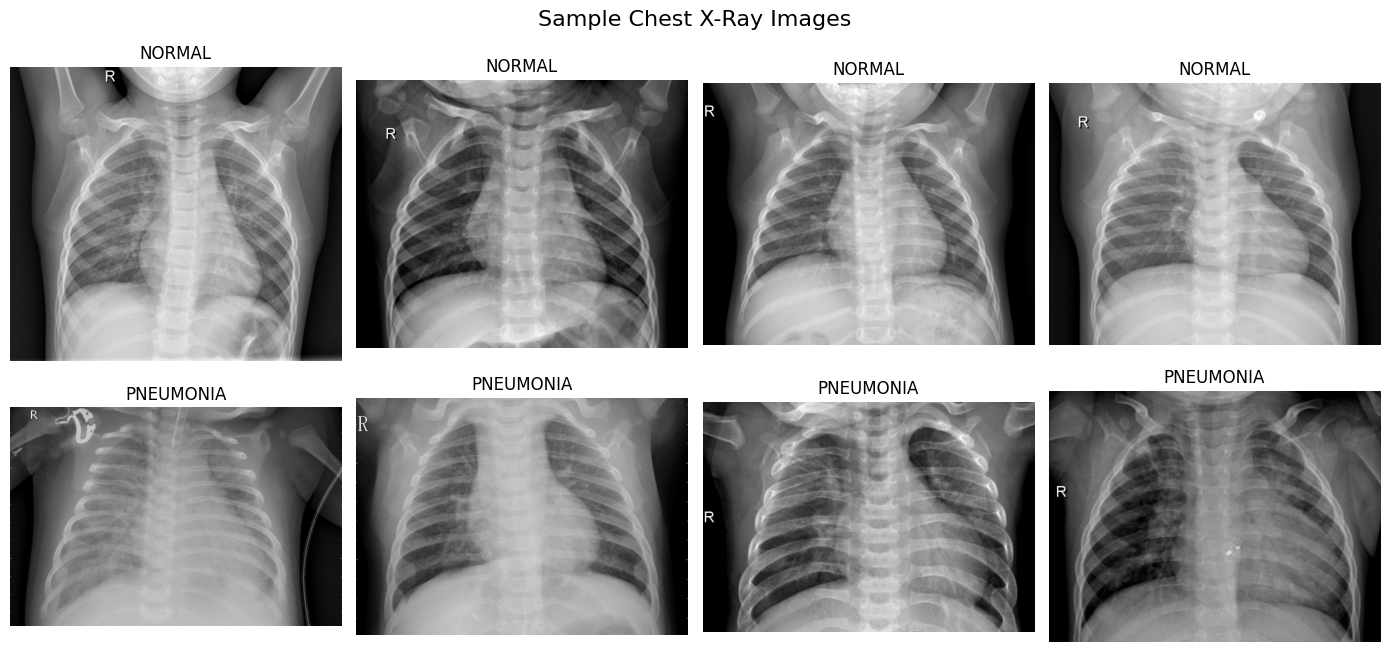

In [3]:
# Display sample images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Normal samples
normal_imgs = os.listdir(train_dir + '/NORMAL')[:4]
for i, img_name in enumerate(normal_imgs):
    img = plt.imread(train_dir + '/NORMAL/' + img_name)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('NORMAL')
    axes[0, i].axis('off')

# Pneumonia samples
pneumonia_imgs = os.listdir(train_dir + '/PNEUMONIA')[:4]
for i, img_name in enumerate(pneumonia_imgs):
    img = plt.imread(train_dir + '/PNEUMONIA/' + img_name)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('PNEUMONIA')
    axes[1, i].axis('off')

plt.suptitle('Sample Chest X-Ray Images', fontsize=16)
plt.tight_layout()
plt.show()

## S — Scrub
### Image Preprocessing & Data Augmentation
Normalizing pixel values and augmenting training data to improve model generalization.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixels 0-1
    rotation_range=10,        # random rotation
    zoom_range=0.1,           # random zoom
    horizontal_flip=True      # random flip
)

# Test and val data - only normalization
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Classes:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


## E — Explore
### Data prepared for training
- Training: **5,216 images** with augmentation
- Test: **624 images**
- Validation: **16 images**
- Pixel values normalized to **0-1** range
- Classes: NORMAL=0, PNEUMONIA=1

##  M — Model
### Convolutional Neural Network Architecture

In [6]:
from tensorflow.keras.callbacks import EarlyStoppingfrom tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten and Dense
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\micha\PycharmProjects\Chest_xray_classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping - stops training if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

print("Training complete!")

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9030 - loss: 0.2330 - val_accuracy: 0.6875 - val_loss: 0.5941
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 557ms/step - accuracy: 0.9254 - loss: 0.1836 - val_accuracy: 0.8125 - val_loss: 0.5727
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.9404 - loss: 0.1624 - val_accuracy: 0.8125 - val_loss: 0.5059
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 578ms/step - accuracy: 0.9477 - loss: 0.1409 - val_accuracy: 0.7500 - val_loss: 0.6790
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 581ms/step - accuracy: 0.9507 - loss: 0.1280 - val_accuracy: 0.7500 - val_loss: 0.6939
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 588ms/step - accuracy: 0.9548 - loss: 0.1180 - val_accuracy: 0.6250 - val_loss: 1.0411
Training complete!
